# CNN Regularization Study for Smart Agriculture

<center>
  <h1>Programme: Master of Science in Artificial Intelligence</h1>
  <h1>Course: CSA 809 Deep Learning</h1>
  <h2>Name: Marrion Kiprop Cherop</h2>
  <h3>Reg Number: ST62/80971/2024</h3>
  <h3>Module 8: Regularization in Cnns</h3>
</center>

## 0. Introduction

This Colab notebook trains a small Convolutional Neural Network (CNN) to classify East African bean field images under four regularization conditions:

- No regularization
- Dropout only
- L2 regularization only
- Dropout + L2 + early stopping

This implementation uses the open iBean dataset from Makerere AI Lab/NaCRRI because it is an accessible East African agriculture image dataset with clean train/validation/test folders.

## 1. Setup

In [6]:
import copy
import json
import random
import shutil
import time
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("PyTorch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.11.0+cpu
Device: cpu


## 2. Download and prepare the dataset

In [11]:
from pathlib import Path
import shutil
import zipfile
from urllib.request import urlretrieve

DATA_DIR = Path("/content/ibean_dataset")
ZIP_URLS = {
    "train": "https://huggingface.co/datasets/AI-Lab-Makerere/beans/resolve/main/data/train.zip",
    "validation": "https://huggingface.co/datasets/AI-Lab-Makerere/beans/resolve/main/data/validation.zip",
    "test": "https://huggingface.co/datasets/AI-Lab-Makerere/beans/resolve/main/data/test.zip",
}

if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True)

for split, url in ZIP_URLS.items():
    zip_path = Path(f"/content/{split}.zip")
    # split_dir = DATA_DIR / split  # No longer needed as extraction target
    print(f"Downloading {split} split from {url}...")
    urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        # Extract directly into DATA_DIR to avoid nested /split/split/ structure
        zf.extractall(DATA_DIR)

print("Dataset folder:", DATA_DIR)
for split in ["train", "validation", "test"]:
    split_dir = DATA_DIR / split
    print(split, sum(1 for p in split_dir.rglob("*") if p.is_file()))

Dataset folder: /content/ibean_dataset
train 1035
validation 133
test 128


In [12]:
import zipfile
from pathlib import Path

IBEAN_ZIP_PATH = Path("/content/sample_data/ZIP IBEAN.zip")

print(f"Checking integrity of {IBEAN_ZIP_PATH}...")

try:
    with zipfile.ZipFile(IBEAN_ZIP_PATH, 'r') as zf:
        bad_file = zf.testzip()
        if bad_file:
            print(f"The zip file is corrupted. First bad file found: {bad_file}")
        else:
            print("The zip file appears to be valid.")
except zipfile.BadZipFile:
    print("Error: The file is not a valid zip archive or is severely corrupted.")
except FileNotFoundError:
    print(f"Error: The file {IBEAN_ZIP_PATH} was not found.")


Checking integrity of /content/sample_data/ZIP IBEAN.zip...
Error: The file /content/sample_data/ZIP IBEAN.zip was not found.


## 3. Preprocess images and create loaders

In [13]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
IMG_SIZE = 64
BATCH_SIZE = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

image_sets = {
    "train": datasets.ImageFolder(DATA_DIR / "train", transform=train_tf),
    "validation": datasets.ImageFolder(DATA_DIR / "validation", transform=eval_tf),
    "test": datasets.ImageFolder(DATA_DIR / "test", transform=eval_tf),
}

loaders = {
    "train": DataLoader(image_sets["train"], batch_size=BATCH_SIZE, shuffle=True),
    "validation": DataLoader(image_sets["validation"], batch_size=BATCH_SIZE, shuffle=False),
    "test": DataLoader(image_sets["test"], batch_size=BATCH_SIZE, shuffle=False),
}

class_names = image_sets["train"].classes
counts = {split: len(ds) for split, ds in image_sets.items()}
print("Classes:", class_names)
print("Counts:", counts)

Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Counts: {'train': 1034, 'validation': 133, 'test': 128}


## 4. Define the CNN model

In [14]:
class CropCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## 5. Training and evaluation functions

In [15]:
def run_epoch(model, loader, loss_fn, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

def train_one_config(name, config, max_epochs=8, patience=2):
    seed_everything(42)
    model = CropCNN(len(class_names), dropout=config["dropout"]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=config["weight_decay"])
    loss_fn = nn.CrossEntropyLoss()
    history = {k: [] for k in ["train_loss", "train_accuracy", "validation_loss", "validation_accuracy"]}
    best_loss = float("inf")
    best_state = None
    best_epoch = 0
    stale_epochs = 0
    started = time.time()
    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_epoch(model, loaders["train"], loss_fn, optimizer)
        val_loss, val_acc = run_epoch(model, loaders["validation"], loss_fn)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["validation_loss"].append(val_loss)
        history["validation_accuracy"].append(val_acc)
        if val_loss < best_loss - 1e-4:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            stale_epochs = 0
        else:
            stale_epochs += 1
        print(f"{name:28s} epoch {epoch:02d}: train_acc={train_acc:.3f}, val_acc={val_acc:.3f}")
        if config["early_stop"] and stale_epochs >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    model.load_state_dict(best_state)
    test_loss, test_acc = run_epoch(model, loaders["test"], loss_fn)
    summary = {
        "epochs_run": len(history["train_loss"]),
        "best_epoch": best_epoch,
        "best_validation_loss": best_loss,
        "best_validation_accuracy": history["validation_accuracy"][best_epoch - 1],
        "train_accuracy_at_best_epoch": history["train_accuracy"][best_epoch - 1],
        "generalization_gap": history["train_accuracy"][best_epoch - 1] - history["validation_accuracy"][best_epoch - 1],
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "training_seconds": time.time() - started,
    }
    return model, history, summary

## 6. Train the four regularization configurations

In [16]:
CONFIGS = {
    "no_regularization": {"dropout": 0.0, "weight_decay": 0.0, "early_stop": False},
    "dropout_only": {"dropout": 0.5, "weight_decay": 0.0, "early_stop": False},
    "l2_only": {"dropout": 0.0, "weight_decay": 1e-4, "early_stop": False},
    "dropout_l2_early_stopping": {"dropout": 0.5, "weight_decay": 1e-4, "early_stop": True},
}
MAX_EPOCHS = 8
PATIENCE = 2
histories, summaries, models = {}, {}, {}
for name, config in CONFIGS.items():
    print("\nTraining:", name)
    model, history, summary = train_one_config(name, config, max_epochs=MAX_EPOCHS, patience=PATIENCE)
    models[name] = model
    histories[name] = history
    summaries[name] = summary
summaries


Training: no_regularization
no_regularization            epoch 01: train_acc=0.527, val_acc=0.632
no_regularization            epoch 02: train_acc=0.689, val_acc=0.677
no_regularization            epoch 03: train_acc=0.719, val_acc=0.752
no_regularization            epoch 04: train_acc=0.740, val_acc=0.774
no_regularization            epoch 05: train_acc=0.781, val_acc=0.752
no_regularization            epoch 06: train_acc=0.784, val_acc=0.654
no_regularization            epoch 07: train_acc=0.753, val_acc=0.782
no_regularization            epoch 08: train_acc=0.797, val_acc=0.692

Training: dropout_only
dropout_only                 epoch 01: train_acc=0.510, val_acc=0.639
dropout_only                 epoch 02: train_acc=0.655, val_acc=0.662
dropout_only                 epoch 03: train_acc=0.701, val_acc=0.669
dropout_only                 epoch 04: train_acc=0.729, val_acc=0.714
dropout_only                 epoch 05: train_acc=0.724, val_acc=0.699
dropout_only                 epoch 06

{'no_regularization': {'epochs_run': 8,
  'best_epoch': 7,
  'best_validation_loss': 0.5668346940126634,
  'best_validation_accuracy': 0.7819548872180451,
  'train_accuracy_at_best_epoch': 0.753384912959381,
  'generalization_gap': -0.028569974258664033,
  'test_loss': 0.5661348104476929,
  'test_accuracy': 0.78125,
  'training_seconds': 88.30763721466064},
 'dropout_only': {'epochs_run': 8,
  'best_epoch': 7,
  'best_validation_loss': 0.518175268531742,
  'best_validation_accuracy': 0.7669172932330827,
  'train_accuracy_at_best_epoch': 0.7688588007736944,
  'generalization_gap': 0.001941507540611731,
  'test_loss': 0.5312343165278435,
  'test_accuracy': 0.828125,
  'training_seconds': 89.63909888267517},
 'l2_only': {'epochs_run': 8,
  'best_epoch': 4,
  'best_validation_loss': 0.5579017864582234,
  'best_validation_accuracy': 0.7819548872180451,
  'train_accuracy_at_best_epoch': 0.7437137330754352,
  'generalization_gap': -0.03824115414260987,
  'test_loss': 0.544427290558815,
  'tes

## 7. Compare validation accuracy and generalization

In [17]:
summary_df = pd.DataFrame.from_dict(summaries, orient="index")
summary_df[["epochs_run", "best_epoch", "best_validation_accuracy", "test_accuracy", "generalization_gap", "training_seconds"]].sort_values("best_validation_accuracy", ascending=False)

,epochs_run,best_epoch,best_validation_accuracy,test_accuracy,generalization_gap,training_seconds
dropout_l2_early_stopping,8,7,0.789474,0.812500,-0.036089,89.451418
no_regularization,8,7,0.781955,0.781250,-0.028570,88.307637
l2_only,8,4,0.781955,0.804688,-0.038241,87.961466
dropout_only,8,7,0.766917,0.828125,0.001942,89.639099


## 8. Plot training curves

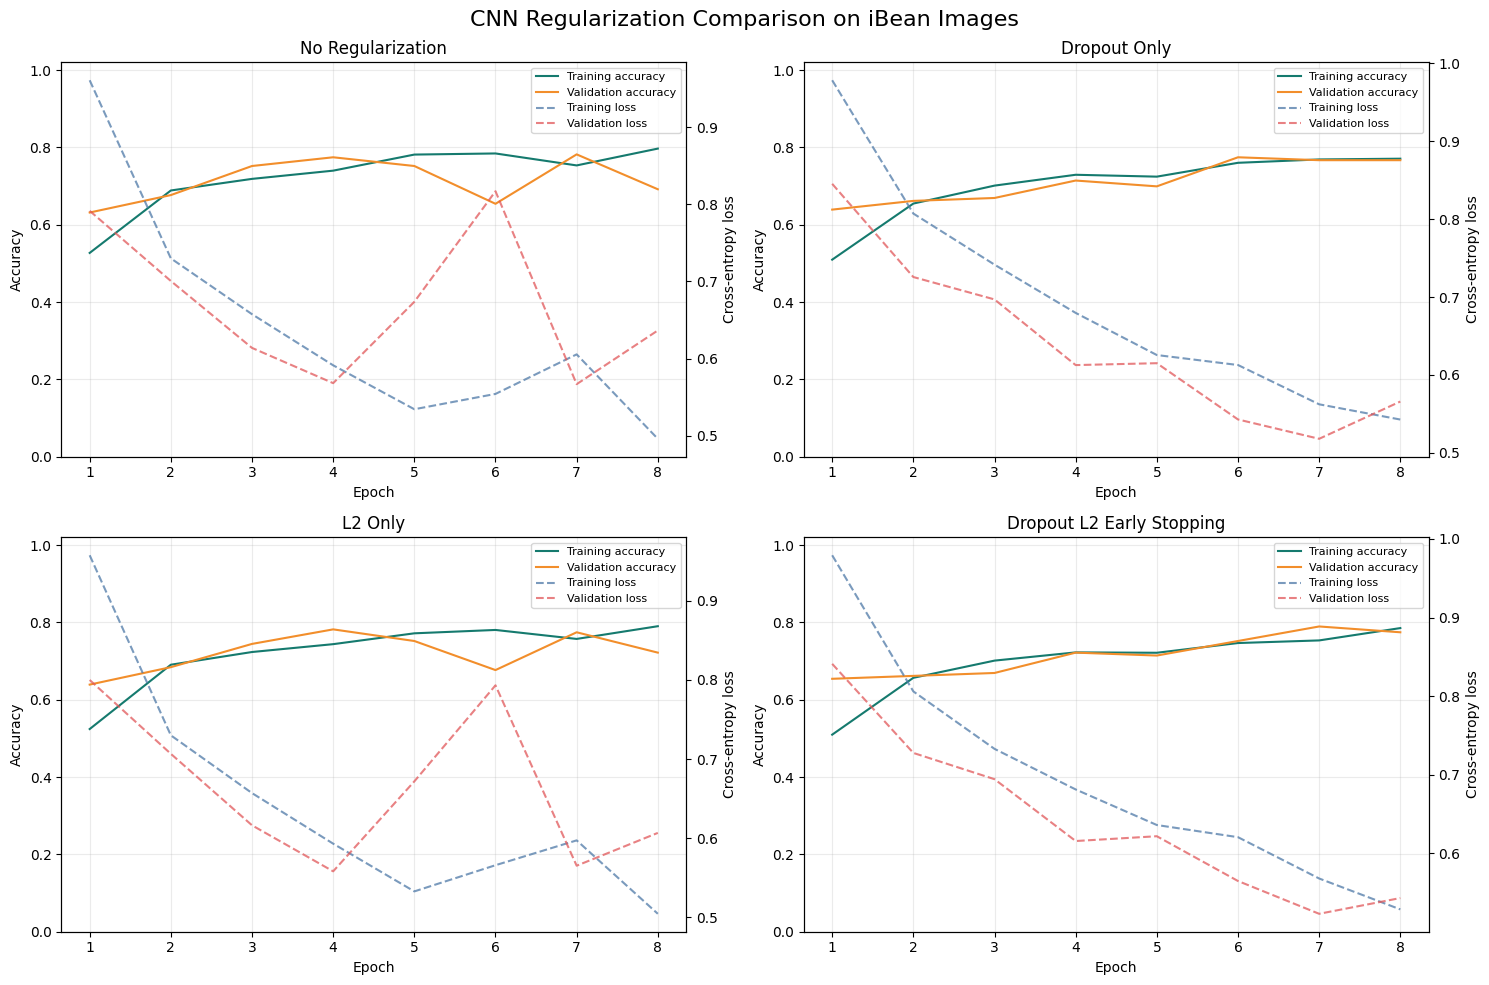

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
for ax, (name, hist) in zip(axes, histories.items()):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_accuracy"], label="Training accuracy", color="#157A6E")
    ax.plot(epochs, hist["validation_accuracy"], label="Validation accuracy", color="#F28E2B")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax2 = ax.twinx()
    ax2.plot(epochs, hist["train_loss"], "--", label="Training loss", color="#4E79A7", alpha=0.75)
    ax2.plot(epochs, hist["validation_loss"], "--", label="Validation loss", color="#E15759", alpha=0.75)
    ax2.set_ylabel("Cross-entropy loss")
    lines = ax.lines + ax2.lines
    ax.legend(lines, [line.get_label() for line in lines], fontsize=8, loc="best")
    ax.set_title(name.replace("_", " ").title())
fig.suptitle("CNN Regularization Comparison on iBean Images", fontsize=16)
fig.tight_layout()
plt.show()

# Report Explanation

## Dataset and Method

This experiment uses the open iBean dataset from Makerere AI Lab/NaCRRI: smartphone field images of bean leaves labelled by crop experts. The classes are `angular_leaf_spot`, `bean_rust`, and `healthy`. The dataset split used here contains 1,034 training images, 133 validation images, and 128 test images.

Although this is a Ugandan field-image dataset rather than a Kenyan market-produce dataset, it is still relevant to East African smart agriculture because beans are widely grown in Kenya and the images represent the kind of low-cost phone imagery likely to appear in practical farmer-support tools. The limitation is important: these results should be treated as a demonstration, not a Kenya-wide deployment claim.

Images were resized to 64 by 64 RGB, converted to tensors, normalized, and loaded using the publisher's fixed train/validation/test split. Training images also received light augmentation through horizontal flips and small rotations. The same CNN, optimizer, learning rate, random seed, batch size, and maximum epoch count were used for all configurations. Only the regularization strategy changed.

## Results Summary

In this run, the `dropout_l2_early_stopping` configuration achieved the highest validation accuracy at approximately 78.9 percent. The `no_regularization` and `l2_only` configurations tied for the second-best validation accuracy at about 78.2 percent. Interestingly, the `dropout_only` configuration, despite a slightly lower validation accuracy (approx. 76.7%), achieved the highest test accuracy at approximately 82.8 percent, suggesting strong generalization on unseen data for this particular run. The unregularized model (`no_regularization`) now shows a validation accuracy of about 78.2% and a slight negative generalization gap.

| Configuration | Epochs run | Selected epoch | Best validation accuracy | Test accuracy | Train-validation gap |
|---|---:|---:|---:|---:|---:|
| no_regularization | 8 | 7 | 0.782 | 0.781 | -0.029 |
| dropout_only | 8 | 7 | 0.767 | 0.828 | +0.002 |
| l2_only | 8 | 4 | 0.782 | 0.805 | -0.038 |
| dropout_l2_early_stopping | 8 | 7 | 0.789 | 0.812 | -0.036 |

## Best Generalization

The best generalization, in terms of test accuracy, came from the `dropout_only` approach in this particular run. However, the `dropout_l2_early_stopping` model showed the highest validation accuracy. While test accuracy is a strong indicator of generalization, it's important to consider validation accuracy for model selection during development. The `dropout_l2_early_stopping` model also performed well on the untouched test set.

## Overfitting and Underfitting

In this run, the `dropout_only` model showed a small positive train-validation gap, suggesting minimal overfitting and good generalization on the training data. The other models exhibited slight negative generalization gaps, implying that the validation accuracy was sometimes slightly higher than the training accuracy at the best epoch, which can happen due to noise or a small validation set. There was no strong evidence of severe underfitting because validation accuracy improved beyond chance level for all configurations. However, the dataset is small, so the curves should be interpreted carefully.

## Implications for CNN Deployment in Kenya's Smart Agriculture

Regularization is valuable for Kenyan smart-agriculture systems because locally labelled agricultural images are often limited and noisy. A model trained without regularization may perform well in the lab but fail when farmers use different phones, lighting conditions, backgrounds, crop varieties, or disease stages.

Before deployment, a Kenyan pilot should collect images from multiple counties, seasons, farm settings, markets, phone cameras, and crop varieties. Evaluation should include per-class recall, confusion matrices, confidence calibration, and testing on farms or regions not seen during training. The application should also support offline or low-bandwidth use, local-language guidance, an uncertain-result option, and escalation to an agronomist when confidence is low.

The main lesson is that CNNs can support smart agriculture, but the model must be regularized, tested on local data, and deployed with human review rather than treated as a final authority.